In [1]:
# --
import xarray as xr

In [2]:
chla_ds = xr.open_dataset('data/chla_slc_clip_2326.nc')

In [6]:
chla_ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 194, y: 1074, x: 628)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2023-02-06T14:31:21.521000 ... 202...
  * y            (y) float64 9kB 6.534e+06 6.534e+06 ... 6.523e+06 6.523e+06
  * x            (x) float64 5kB 3.575e+05 3.575e+05 ... 3.638e+05 3.638e+05
Data variables:
    spatial_ref  int64 8B ...
    chla         (time, y, x) float64 1GB ...
    slc          (time, y, x) float32 523MB ...

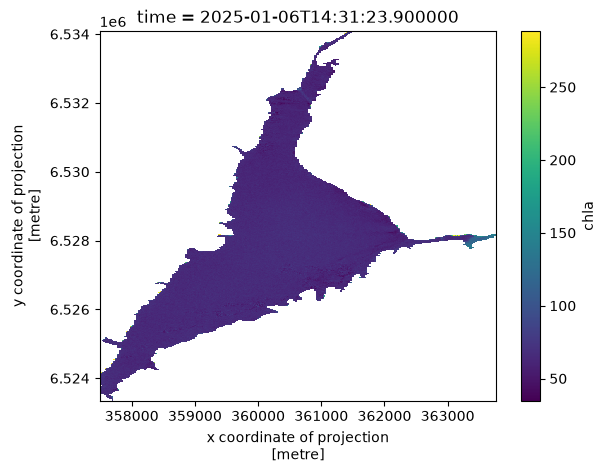

In [7]:
chla_ds.isel(time=120)['chla'].plot()

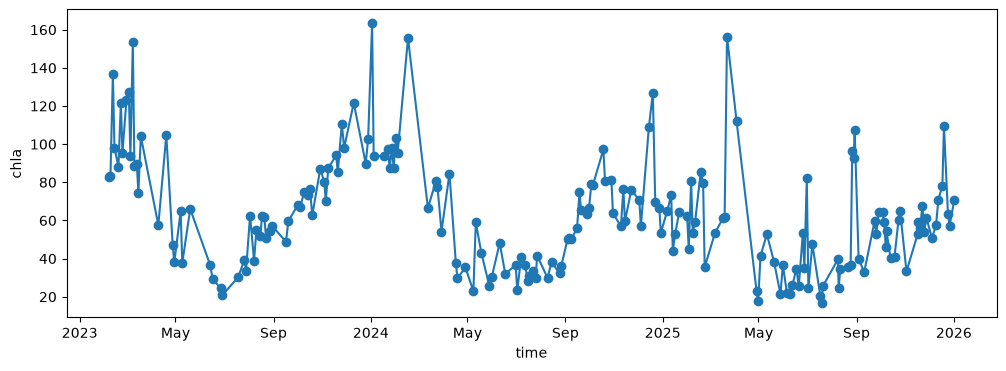

In [43]:
# --
ts_whole_mean = chla_ds['chla'].mean(dim=['x', 'y'], skipna=True)
ts_whole_mean.plot(marker='o', linestyle='-', figsize=(12, 4))

### K-means analysis

In [10]:
# GET SST VALUES AS A MATRIX
X = chla_ds['chla'].values

In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans  # or MiniBatchKMeans, see below

# X shape: (time, x, y) = (194, 1074, 628)
T, NX, NY = X.shape

# DATA RESHAPING -> (pixels, time)
X_resh = X.reshape(T, NX * NY).T.astype(np.float32)   # (674472, 194)

# MASK NAN VALUES (drop pixels with any NaN instead of filling with a fake value)
valid = ~np.isnan(X_resh).any(axis=1)
X_valid = X_resh[valid]

# DATA SCALING (each time step scaled across all pixels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_valid)

# KMEANS
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
labels_valid = kmeans.fit_predict(X_scaled)

# REBUILD THE MAP (NaN where the pixel was invalid)
labels = np.full(NX * NY, np.nan, dtype=np.float32)
labels[valid] = labels_valid
label_map = labels.reshape(NX, NY)

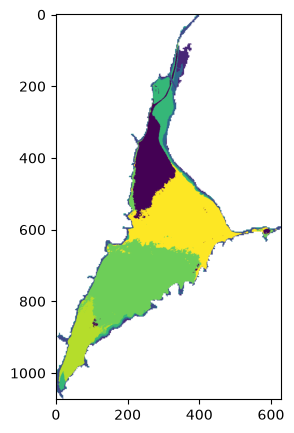

In [19]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(label_map)

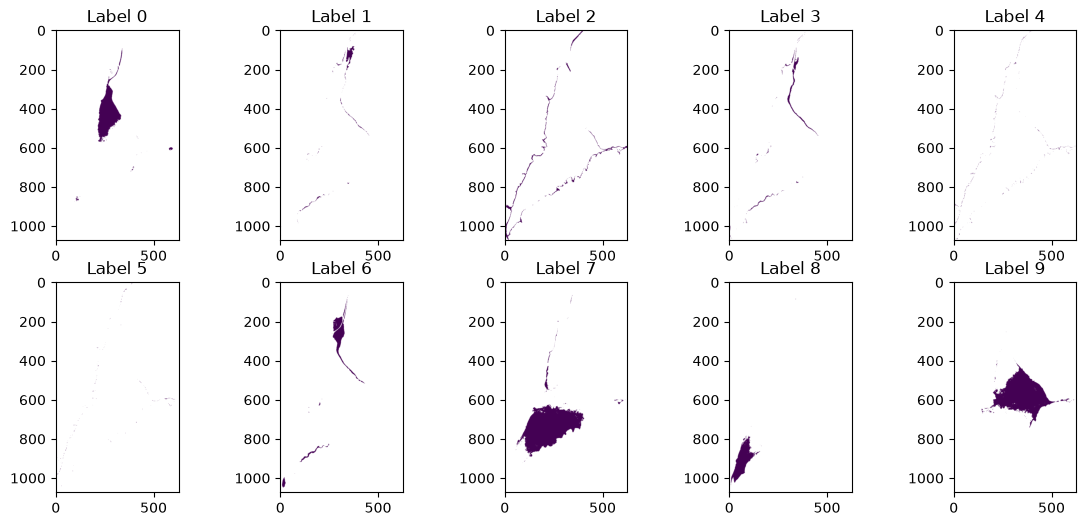

In [31]:
fig, ax = plt.subplots(2, 5, figsize=(14, 6))
ax = ax.flatten()

for idx, l in enumerate(np.unique(labels)[:-1]):
    #print(l)
    ax[idx].imshow(np.where(label_map == l, label_map, np.nan))
    ax[idx].set_title(f'Label {idx}')

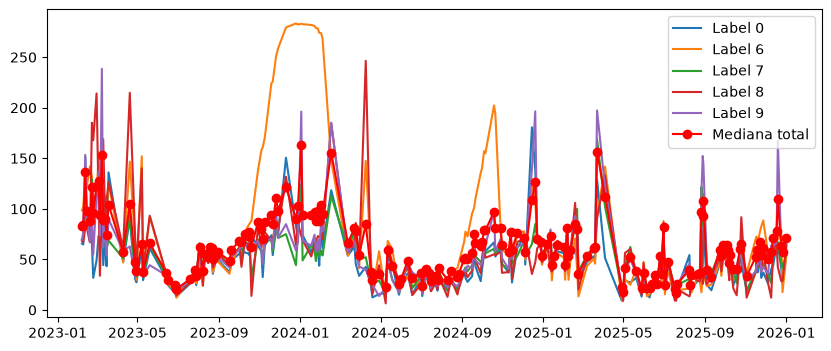

In [48]:
# --
labels_anls = [0, 6, 7, 8, 9]

# --
fig, ax = plt.subplots(figsize=(10, 4))

# --
for idx, l in enumerate([0, 6, 7, 8, 9]):
    #print(l)
    data_label = np.where(label_map == l, chla_da, np.nan)
    data_label_mean = np.nanmean(data_label, axis=(1, 2))
    
    ax.plot(chla_ds.time.values, data_label_mean, label=f'Label {l}')
    #ax[idx].imshow(np.where(label_map == l, chla_da , np.nan))
    #ax[idx].set_title(f'Label {idx}')
    
# --
ax.plot(chla_ds.time.values, ts_whole_mean.values, color='red', marker='o', label='Mediana total')

# --
ax.legend(loc='best')